In [19]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [20]:
import awkward as ak
import numpy as np
from python.analysis import cross_section, Application, Master
from apps import cex_analysis_input
cross_section.SetPlotStyle(dpi = 100, dark = True)

In [21]:
cfg = Application.ApplicationArguments.ResolveConfig(Master.LoadConfiguration("/home/bhuller/work/analysis_new_selection/analysis_config_new_selection.json"))

In [22]:
ais = {k : cross_section.AnalysisInput.FromFile(v) for k, v in cfg.analysis_input.items()}

In [35]:
def log_plot(param : str, tags : cross_section.Tags.Tags, bins : int | list, x_label : str, x_range : list[float] = None):
    mc = getattr(ais["mc"], param)
    data = getattr(ais["data"], param)
    if x_range is None:
        x_range = [np.percentile(cross_section.ak.flatten([mc, data]), 0.05), np.percentile(cross_section.ak.flatten([mc, data]), 99.95)]  
    cross_section.Plots.PlotTagged(
        mc,
        tags,
        x_label = x_label,
        x_range = x_range,
        bins = bins,
        norm = False,
        y_scale="linear")
    return

def log_shape_plot(param : str, tags : cross_section.Tags.Tags, bins : int | list, x_label : str, x_range : list[float] = None, newFigure : bool = True):
    mc = getattr(ais["mc"], param)
    data = getattr(ais["data"], param)
    if x_range is None:
        x_range = [np.percentile(cross_section.ak.flatten([mc, data]), 0.05), np.percentile(cross_section.ak.flatten([mc, data]), 99.95)]  
    cross_section.Plots.PlotTagged(
        mc,
        tags,
        x_label = x_label,
        x_range = x_range,
        bins = bins,
        norm = True,
        stacked = False,
        reverse_sort = True,
        histtype="step",
        y_scale="log",
        newFigure=newFigure)
    return


In [40]:
reco_params = {
    "KE_ff_reco" :        {"bins" : 20, "x_label" : "Reco front facing KE (MeV)", "x_range" : None},
    "KE_init_reco" :      {"bins" : 20, "x_label" : "Reco initial KE (MeV)", "x_range" : None},
    "KE_int_reco" :       {"bins" : 20, "x_label" : "Reco interacting (end) KE (MeV)", "x_range" : None},
    "end_z_reco" :        {"bins" : 20, "x_label" : "Reco end z position (cm)", "x_range" : [0, 700]},
    "track_length_reco" : {"bins" : np.append(np.linspace(0, 400, 20), 700), "x_label" : "Reco track length (cm)", "x_range" : None}
}

true_params = {
    "KE_ff_true" :        {"bins" : 20, "x_label" : "True front facing KE (MeV)", "x_range" : None},
    "KE_init_true" :      {"bins" : 20, "x_label" : "True initial KE (MeV)", "x_range" : None},
    "KE_int_true" :       {"bins" : 20, "x_label" : "True interacting (end) KE (MeV)", "x_range" : None},
    "end_z_true" :        {"bins" : 20, "x_label" : "True end z position (cm)", "x_range" : [0, 700]},
    "track_length_true" : {"bins" : np.append(np.linspace(0, 400, 20), 700), "x_label" : "True track length (cm)", "x_range" : None}
}


In [ ]:
import itertools

def make_plots(params, save : bool = False):
    book = cross_section.Plots.PlotBook("comparison_plots", save)

    tags = cross_section.Tags.ExclusiveProcessTags(ais["mc"].exclusive_process)

    for k, v in params.items():
        log_plot(k, tags, **v)
        book.Save()

    for k, v in params.items():
        log_shape_plot(k, tags, **v)
        book.Save()


    for n, (i, j) in cross_section.Plots.IterMultiPlot(list(itertools.product(params, params))):
        mc_i = getattr(ais["mc"], i)
        mc_j = getattr(ais["mc"], j)

        # if i == j:
        #     log_shape_plot(i, tags, **params[i], newFigure = False)
        # else:
        for t in tags.values():
            cross_section.Plots.Plot(mc_i[t.mask], mc_j[t.mask], color = t.colour, label = t.name, xlabel = params[i]["x_label"], ylabel = params[j]["x_label"], linestyle = "", marker="o", alpha = 0.25, markersize=1, newFigure = False, rasterized = True)


        bounds_i = [np.percentile(mc_i, 0.05), np.percentile(mc_i, 99.95)]
        bounds_j = [np.percentile(mc_j, 0.05), np.percentile(mc_j, 99.95)]    
        cross_section.Plots.plt.xlim(bounds_i)
        cross_section.Plots.plt.ylim(bounds_j)

    book.Save()
    
    book.close()
# with cross_section.Plots.MultiPlot(len(params)**2) as mp:
#     for i, j in itertools.product(params, params):


/home/bhuller/xs_analysis/install/miniforge/envs/python3.13/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis/python/analysis/Plots.py:897: UserWarning: pdf has not been opened.
  warnings.warn("pdf has not been opened.")


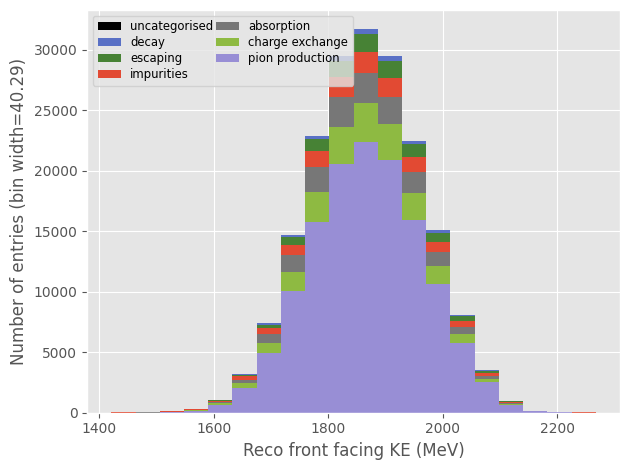

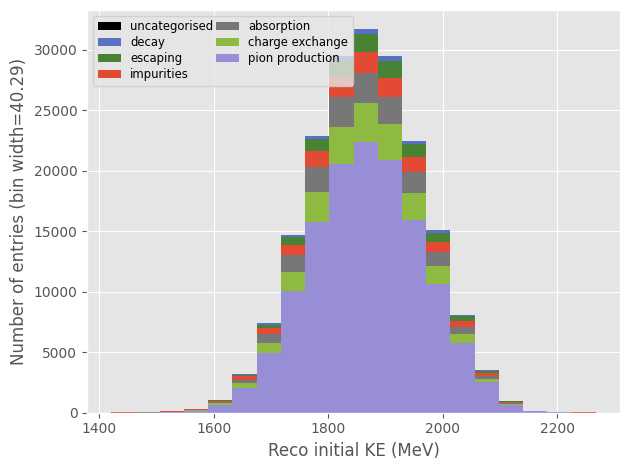

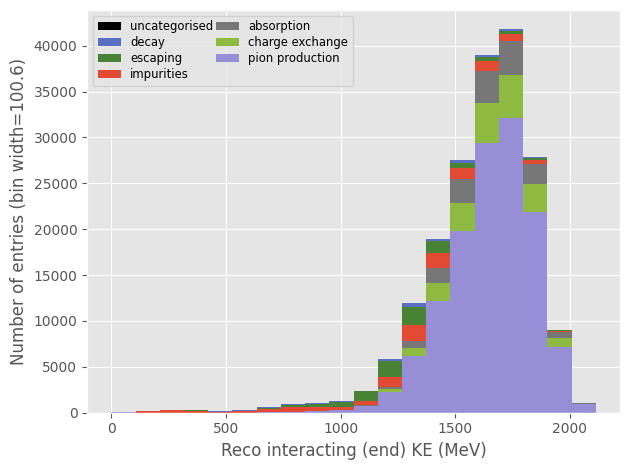

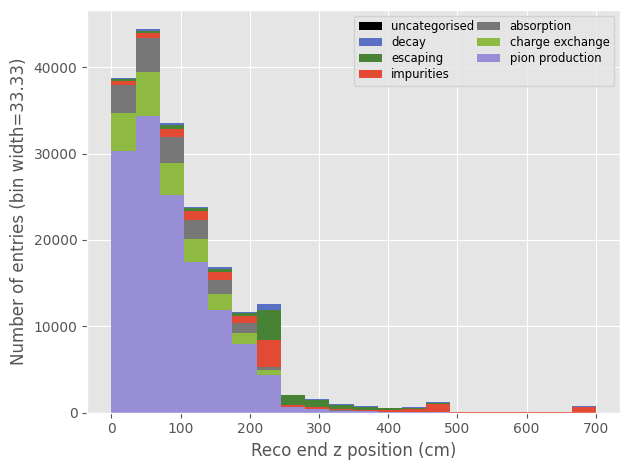

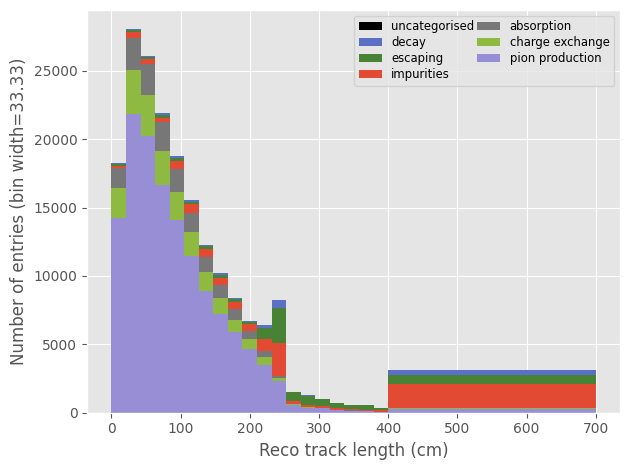

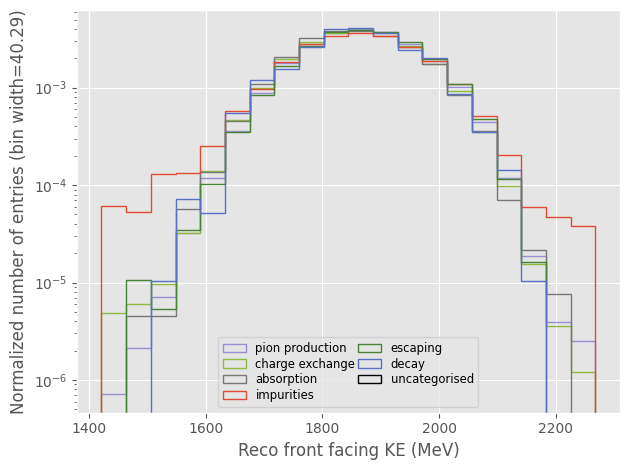

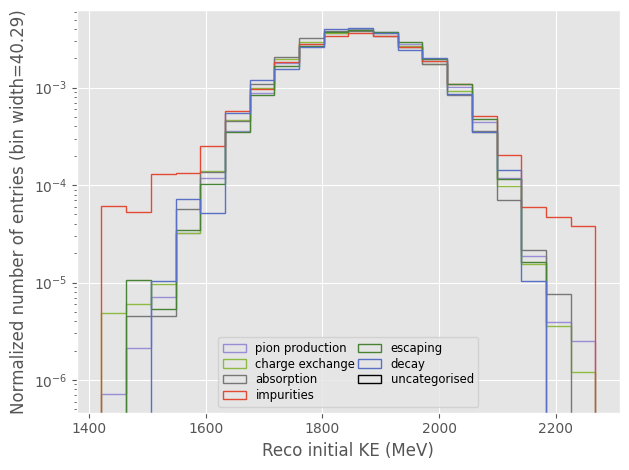

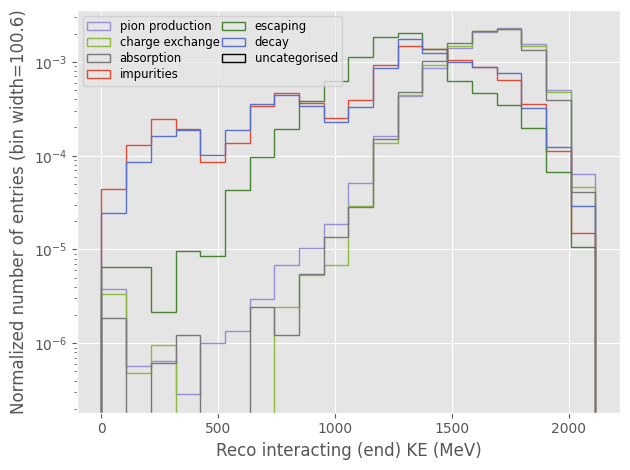

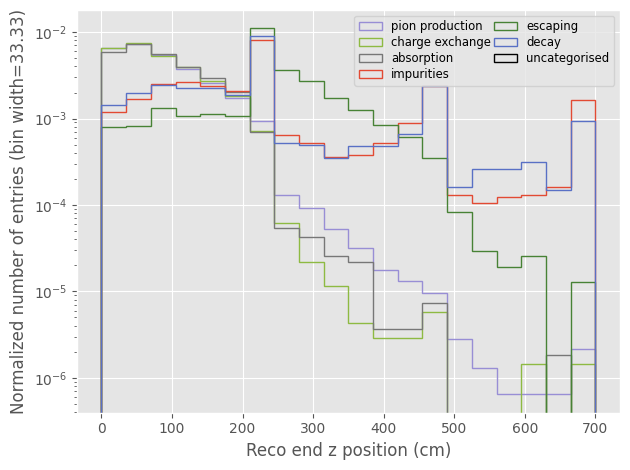

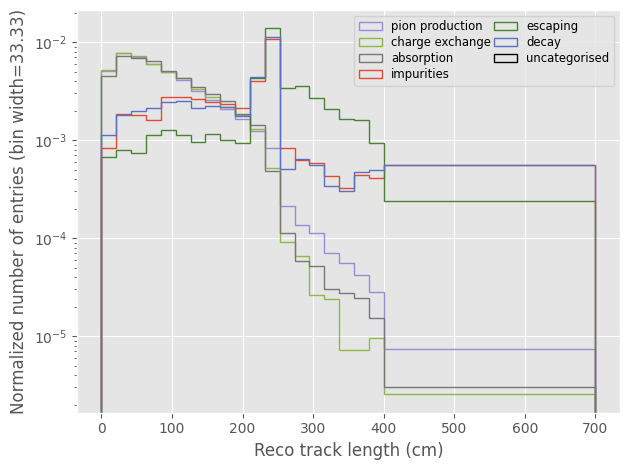

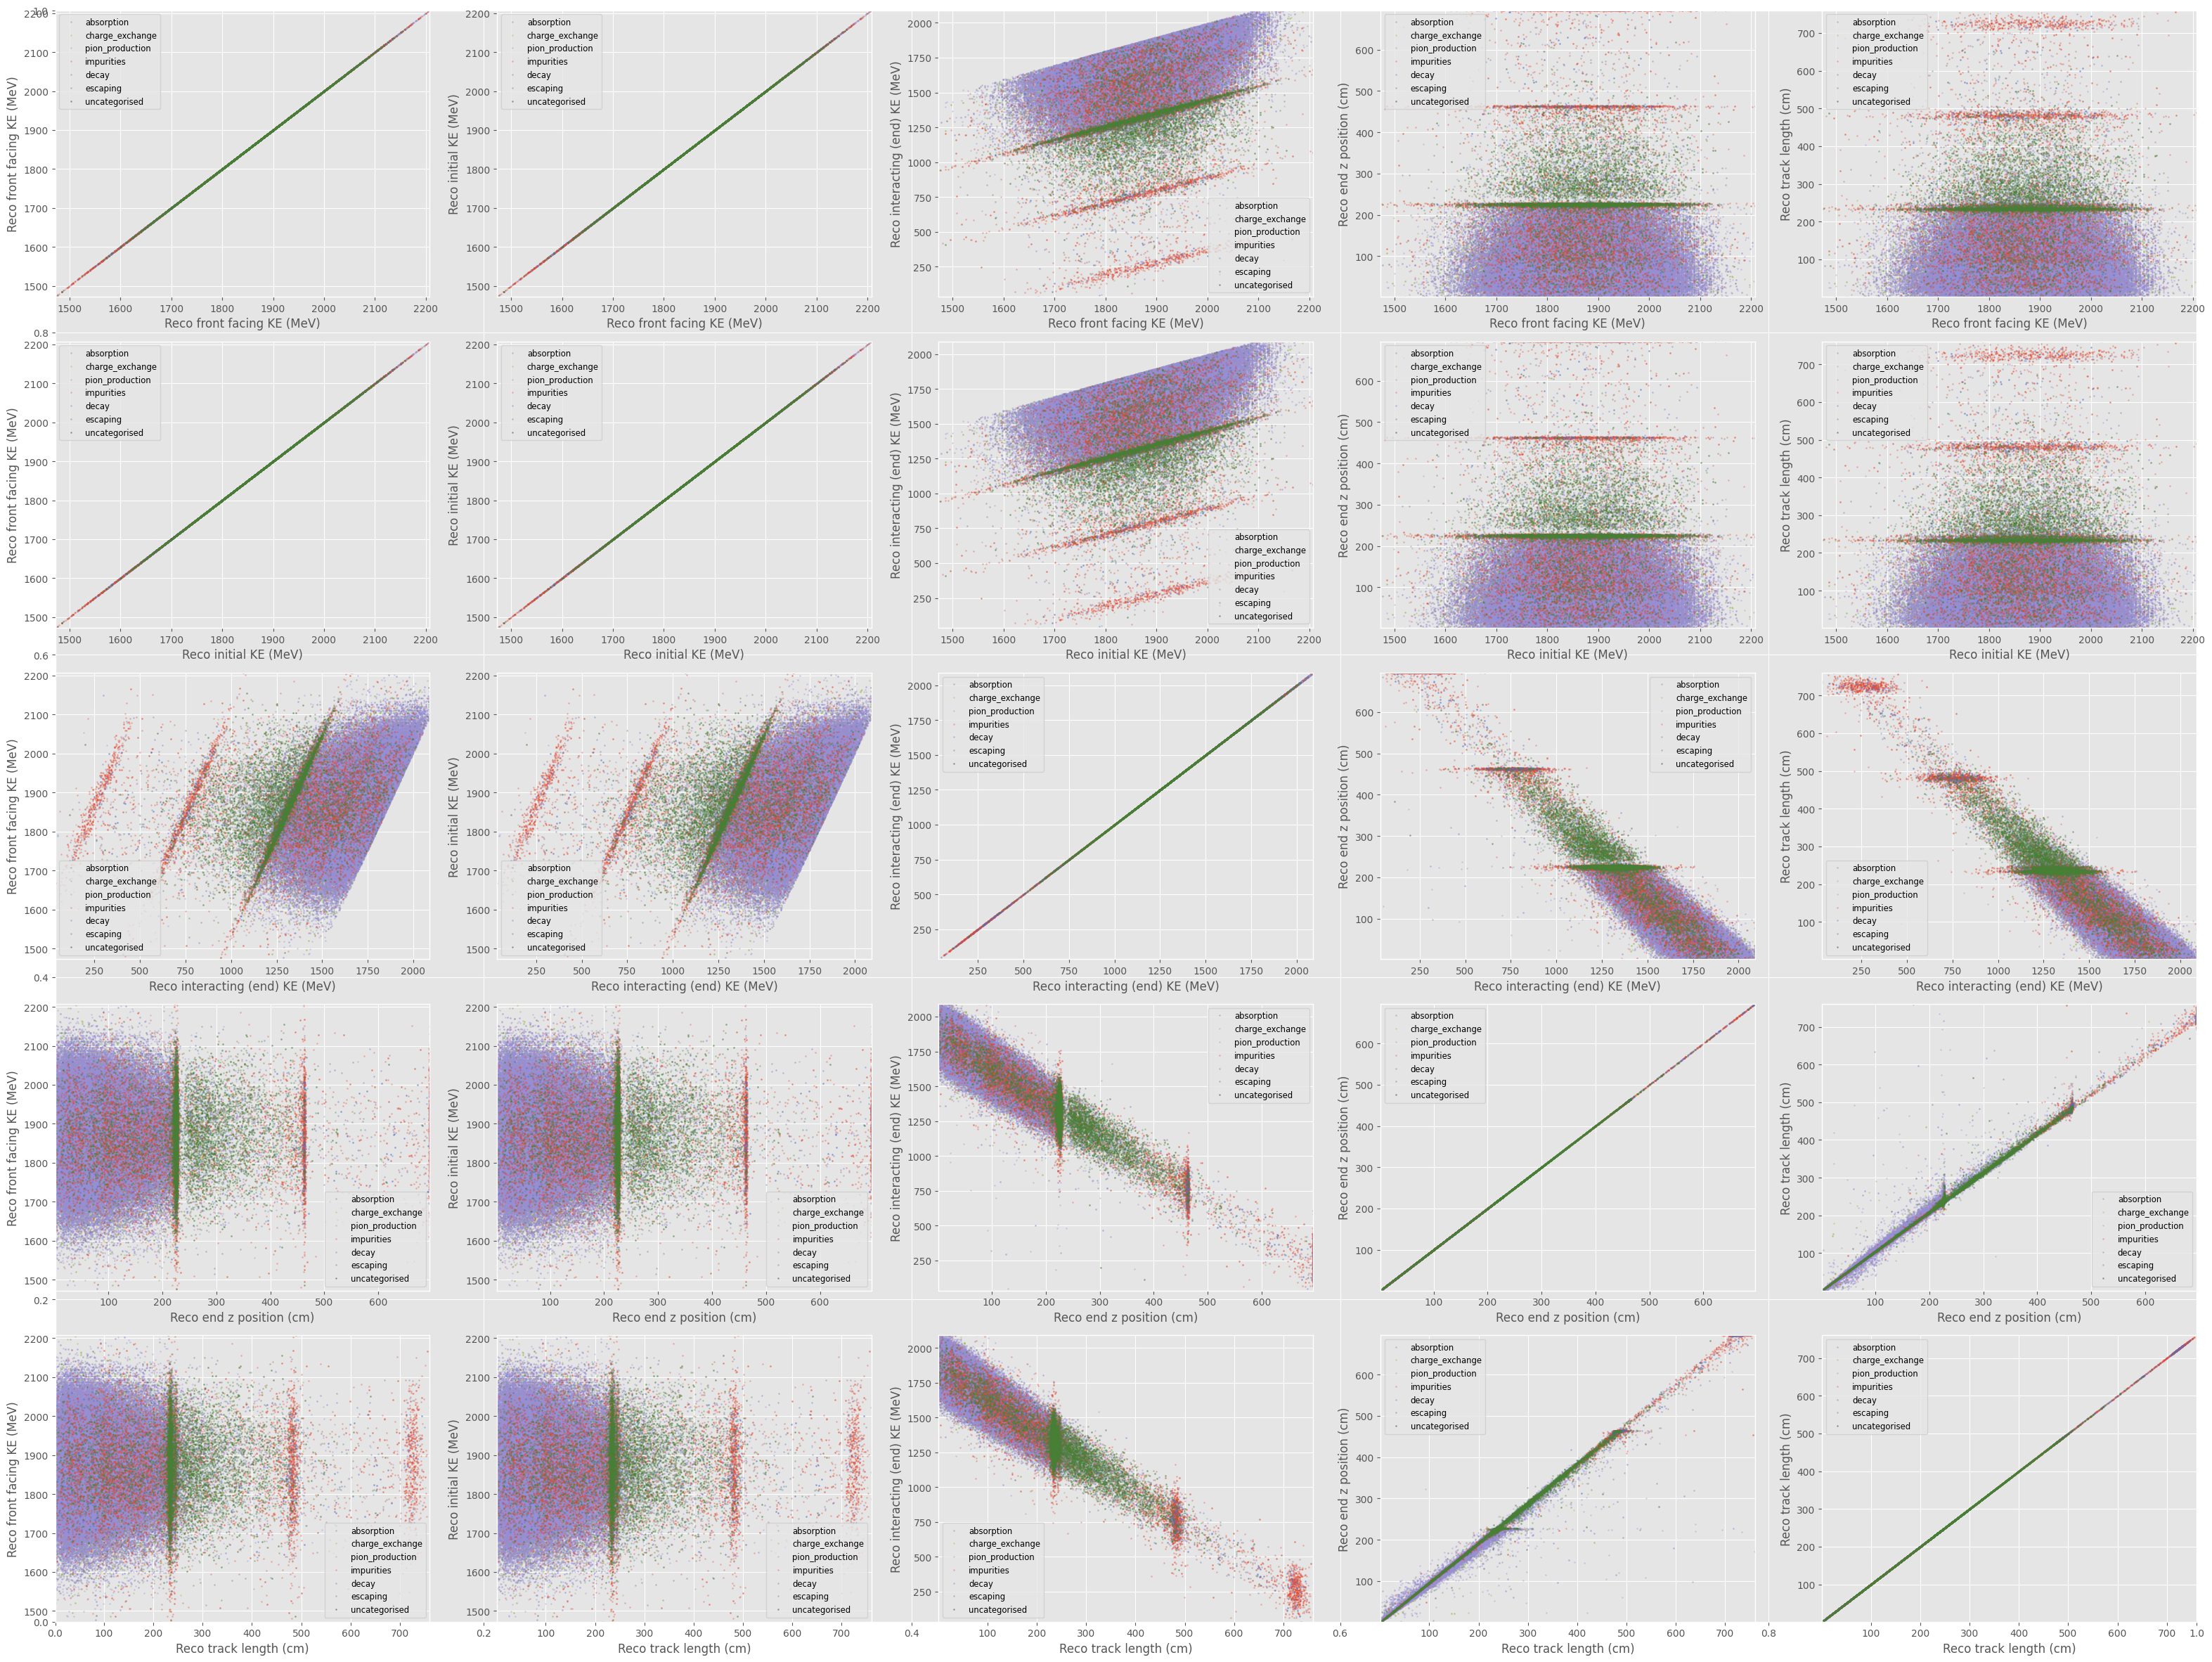

In [41]:
make_plots(reco_params, False)

In [28]:
# Look at reco tracks > 220 + signal
# look at KE

# scatter plots
# make code to visualise the template
# data comparison

In [ ]:
# template
# true process
# true KE end
# true KE init